In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [4]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Digits
data = load_digits()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME-NDT
explainer = LimeTabularExplainer(
    X_train,
    feature_names=[f'pixel_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in range(10)],
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=64,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Explication locale (feature, poids):
[('pixel_19', 0.2677116395654885), ('pixel_20', 0.12497085002840429), ('pixel_36', 0.109913370383249), ('pixel_10', -0.09540649250843125), ('pixel_38', -0.04688208302702543), ('pixel_42', -0.040079869048549106), ('pixel_49', 0.03696428571428572), ('pixel_53', -0.032876426612403815), ('pixel_27', 0.03213668190823657), ('pixel_12', 0.028511962328451733), ('pixel_59', -0.023882163034705424), ('pixel_18', 0.02351190476190476), ('pixel_9', -0.02124999999999999), ('pixel_43', 0.01366071428571429), ('pixel_28', 0.01318571428571428), ('pixel_58', -0.012439912205034723), ('pixel_50', -0.011562179757670772), ('pixel_62', 0.005458319330298573), ('pixel_46', 0.0), ('pixel_52', 0.0), ('pixel_44', 0.0), ('pixel_34', 0.0), ('pixel_61', 0.0), ('pixel_21', 0.0), ('pixel_5', 0.0), ('pixel_33', 0.0), ('pixel_55', 0.0), ('pixel_3', 0.0), ('pixel_2', 0.0), ('pixel_30', 0.0), ('pixel_45', 0.0)

In [5]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=[f'pixel_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in range(10)],
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=10
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('pixel_10', -0.0116727927363064), ('pixel_19', 0.009659414614253604), ('pixel_20', 0.007308994909229154), ('pixel_58', -0.0055989269544164), ('pixel_44', 0.005564700707804395), ('pixel_42', -0.005560664517580772), ('pixel_52', 0.00506837524115718), ('pixel_46', -0.0048646977815397854), ('pixel_38', -0.00463530982349317), ('pixel_61', 0.0034920715119660887)]


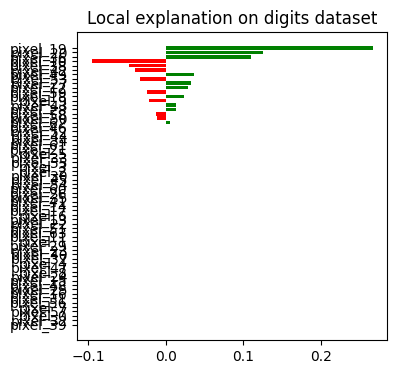

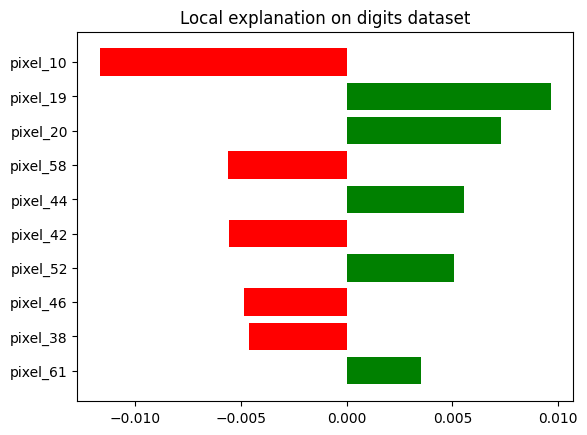

In [10]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on digits dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on digits dataset")
plt.show()